# Workforce Attrition & Flight Risk Analytics Pipeline

## Executive Summary
This notebook implements an end-to-end People Analytics and Machine Learning pipeline designed to evaluate employee turnover drivers, identify flight risks, and quantify financial replacement exposures across departments. 

### Key Business Objectives:
1. **Feature Engineering:** Calculate competitive pay ratios, tenure cohorts, and replacement cost exposure based on structural workforce data.
2. **Exploratory Data Analysis (EDA):** Uncover underlying trends relating engagement scores, manager satisfaction, and compensation equity to actual attrition.
3. **Predictive Modeling:** Train and evaluate classification models to proactively flag high-risk retention targets.

In [ ]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load employee-level dataset
df_emp = pd.read_csv('../csv/attrition_employees.csv', sep='\t')

# Basic structural info and preview the queried features
print(df_emp.info())
df_emp[['comp_ratio', 'estimated_replacement_cost', 'tenure_cohort', 'flight_risk_flag']].head()

<class 'pandas.DataFrame'>
RangeIndex: 4228 entries, 0 to 4227
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   base_salary                 4228 non-null   float64
 1   performance_rating          4228 non-null   int64  
 2   tenure_years                4088 non-null   float64
 3   age                         4228 non-null   int64  
 4   engagement_score            3868 non-null   float64
 5   manager_satisfaction        3769 non-null   float64
 6   work_life_balance_score     3762 non-null   float64
 7   is_attrition                4228 non-null   int64  
 8   comp_ratio                  4228 non-null   float64
 9   estimated_replacement_cost  4228 non-null   float64
 10  tenure_cohort               4228 non-null   str    
 11  flight_risk_flag            4228 non-null   int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 396.5 KB
None


,comp_ratio,estimated_replacement_cost,tenure_cohort,flight_risk_flag
0,0.833,27172.484,0-1 Year (Onboarding),0
1,1.165,38004.460,1-3 Years (Mid-Tenure),0
2,1.051,34272.660,0-1 Year (Onboarding),0
3,0.900,29346.828,1-3 Years (Mid-Tenure),1
4,1.216,39681.404,1-3 Years (Mid-Tenure),0


## Exploratory Data Analysis (EDA)
Before moving into data cleaning or modeling, I explore the macro-level structure of the workforce data. I examine the previously queried aggregate departmental turnover rates and financial replacement exposures, followed by distribution checks on individual employee metrics.

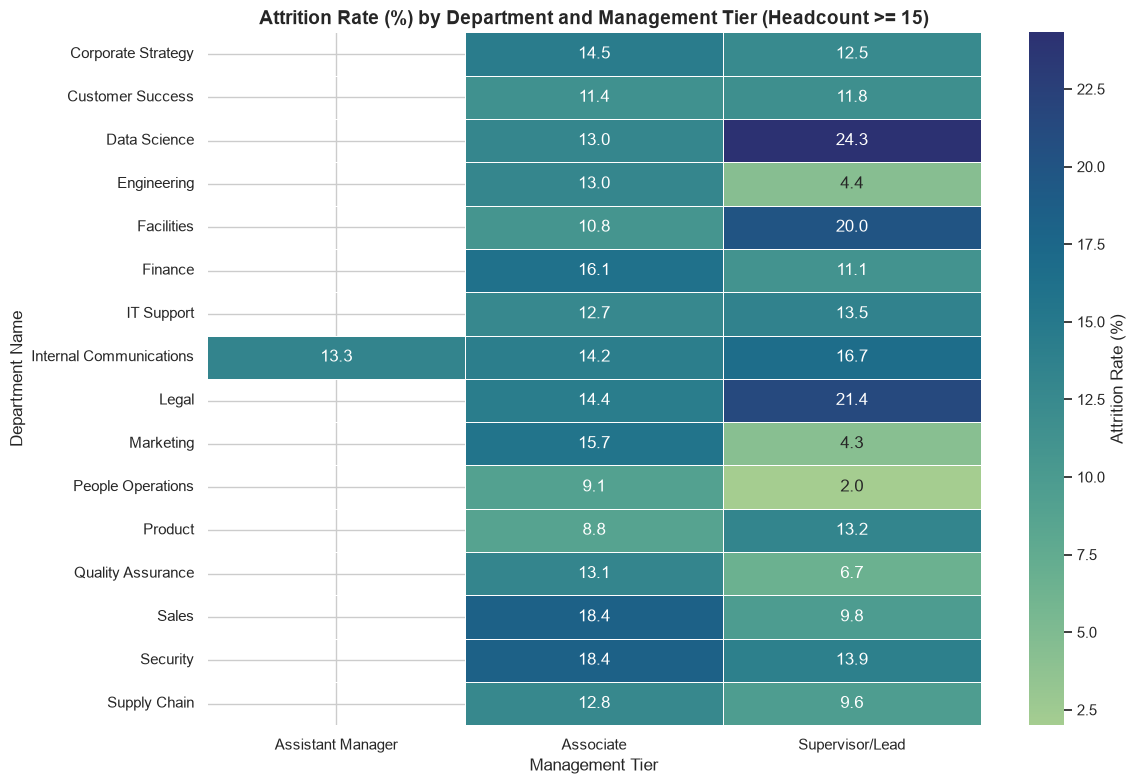

In [62]:
# Load aggregate department data to evaluate macro-level turnover and cost exposure
df_agg = pd.read_csv('../csv/attrition_aggregate.csv', sep='\t')

# Filter out small sample sizes (headcount < 15) to remove statistical noise
df_filtered = df_agg[df_agg['total_headcount'] >= 15].copy()

# Pivot data into a matrix format (Departments vs. Management Tiers)
pivot_df = df_filtered.pivot_table(
    index='department_name', 
    columns='management_tier', 
    values='attrition_rate_pct'
)

# Heatmap visualization of attrition rates by department and management tier
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".1f", 
    cmap="crest", 
    cbar_kws={'label': 'Attrition Rate (%)'}, 
    linewidths=.5
)
plt.title('Attrition Rate (%) by Department and Management Tier (Headcount >= 15)', fontsize=14, fontweight='bold')
plt.xlabel('Management Tier', fontsize=12)
plt.ylabel('Department Name', fontsize=12)
plt.tight_layout()
plt.show()

### Aggregate Workforce Attrition

1. **Hierarchical Turnover Concentration:**
   The heatmap reveals that turnover is not uniformly distributed across the organization; rather, it clusters heavily within specific department and tier combinations. For instance, **Data Science Supervisors/Leads** exhibit the highest systemic attrition risk at **24.3%**, signaling potential burnout, retention friction, or external market poaching for mid-to-senior technical leadership.

2. **Operational Vulnerabilities:**
   * **Sales and Security** show elevated turnover concentrated heavily among **Associate-tier** staff (both at **18.4%**), pointing toward front-line onboarding or compensation competitiveness challenges in entry-level operations.
   * Conversely, departments like **People Operations** and **Marketing** maintain strong retention among senior tiers, though their mid-tier stability varies.

3. **Strategic Implications for HR:**
   By filtering out low-sample noise (headcounts under 15), leadership can clearly target retention interventions where the financial replacement liability is highest—focusing particularly on technical leadership pathways and front-line associate compensation structures before individuals reach a critical flight risk threshold.

### Employee-Level Visual Distributions
Next, I inspect employee-level distributions (engagement scores and compensation ratios) conditioned against actual attrition outcomes to spot early structural signals.

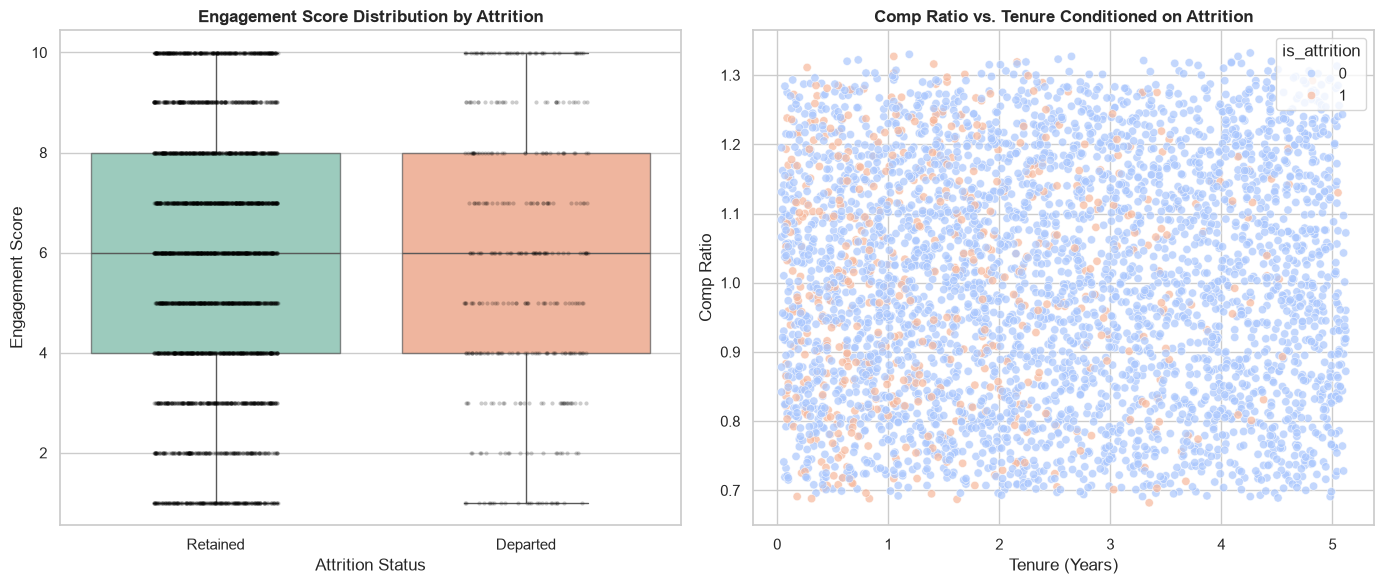

In [66]:
# Clean up data subsets
df_plot = df_emp[(df_emp['tenure_years'] >= 0)].copy()
df_plot['attrition_label'] = df_plot['is_attrition'].map({0: 'Retained', 1: 'Departed'})

# Create subplots to analyze individual employee distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Engagement Score Distribution (Boxplot + Stripplot overlay to show data density)
sns.boxplot(
    data=df_plot,
    x='attrition_label',
    y='engagement_score',
    ax=axes[0],
    palette='Set2',
    hue='attrition_label',
    legend=False,
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df_plot,
    x='attrition_label',
    y='engagement_score',
    ax=axes[0],
    color='black',
    alpha=0.2,
    jitter=0.2,
    size=3
)
axes[0].set_title('Engagement Score Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Engagement Score')

# Compensation Ratio vs. Tenure Conditioned on Attrition
sns.scatterplot(
    data=df_plot,
    x='tenure_years',
    y='comp_ratio',
    alpha=0.7,
    palette='coolwarm',
    hue='is_attrition',
    ax=axes[1]
)
axes[1].set_title('Comp Ratio vs. Tenure Conditioned on Attrition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Comp Ratio')

plt.tight_layout()
plt.show()

### Employee-Level Distribution Insights

1. **Engagement Parity:** 
   The engagement score distributions for both retained and departed employees are nearly identical, with both groups centering around a median score of 6.0. This indicates that standalone survey satisfaction metrics alone do not cleanly separate turnover risks, reinforcing the need for multi-factor models.

2. **Tenure and Compensation Dispersion & Early-Exit Risk:** 
   * Tenure and Compensation Dispersion: The scatter plot mapping compensation ratio against tenure generally demonstrates a broad distribution across the workforce, with departed employees (orange points) appearing across various tenure lengths and comp ratios rather than clustering exclusively in lower-paid cohorts.
   
   * Early-Tenure Concentration: However, a closer inspection reveals a slightly denser concentration of departed employees within the 0 to 1.5-year tenure range, indicating that attrition is disproportionately front-loaded during the critical onboarding and initial integration window.

## Data Cleaning & Missing Value Diagnosis
With the exploratory insights complete, I now examine missing value distributions across survey metrics (engagement, manager satisfaction, work-life balance) and implement a structured imputation approach to preserve sample size while preventing data leakage.

In [53]:
# Check missing value counts per column
print("Missing Value Counts:\n", df_emp.isnull().sum())

# Define numeric feature subsets for imputation
numeric_cols = [
    'base_salary', 'performance_rating', 'tenure_years', 'age', 
    'engagement_score', 'manager_satisfaction', 'work_life_balance_score', 
    'comp_ratio', 'estimated_replacement_cost'
]

# Impute missing values using training median to prevent data leakage in production pipelines
for col in numeric_cols:
    if df_emp[col].isnull().sum() > 0:
        median_val = df_emp[col].median()
        df_emp[col] = df_emp[col].fillna(median_val)

# Verify zero missing values remaining in numeric features
print("\nMissing Values After Imputation:\n", df_emp[numeric_cols].isnull().sum())

Missing Value Counts:
 base_salary                     0
performance_rating              0
tenure_years                  140
age                             0
engagement_score              360
manager_satisfaction          459
work_life_balance_score       466
is_attrition                    0
comp_ratio                      0
estimated_replacement_cost      0
tenure_cohort                   0
flight_risk_flag                0
dtype: int64

Missing Values After Imputation:
 base_salary                   0
performance_rating            0
tenure_years                  0
age                           0
engagement_score              0
manager_satisfaction          0
work_life_balance_score       0
comp_ratio                    0
estimated_replacement_cost    0
dtype: int64


## Logistic Regression Baseline
To establish an interpretable statistical baseline, I begin by training a Logistic Regression model. Because it is a linear model, the resulting coefficients allow for an examination on how individual features linearly impact the log-odds of employee attrition.

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Data Prep: Separate features and target, then apply stratified split
X = df_emp.drop(columns=['is_attrition', 'tenure_cohort'])
y = df_emp['is_attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=90, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")

# 2. Pipeline: Combine median imputation, feature scaling, and balanced class weighting
scaled_log_reg = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=90)
)

# 3. Model Training & Evaluation
scaled_log_reg.fit(X_train, y_train)

y_pred_lr = scaled_log_reg.predict(X_test)
y_prob_lr = scaled_log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report (Scaled & Balanced):\n")
print(classification_report(y_test, y_pred_lr))
print(f"Logistic Regression ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

Training set shape: (3382, 10)
Testing set shape: (846, 10)

Logistic Regression Classification Report (Scaled & Balanced):

              precision    recall  f1-score   support

           0       0.93      0.62      0.75       735
           1       0.22      0.69      0.33       111

    accuracy                           0.63       846
   macro avg       0.57      0.66      0.54       846
weighted avg       0.84      0.63      0.69       846

Logistic Regression ROC-AUC Score: 0.6909


### Logistic Regression Coefficient Analysis
I extract the coefficients directly from the underlying Logistic Regression estimator to compare the relative linear impact of each feature on employee turnover.

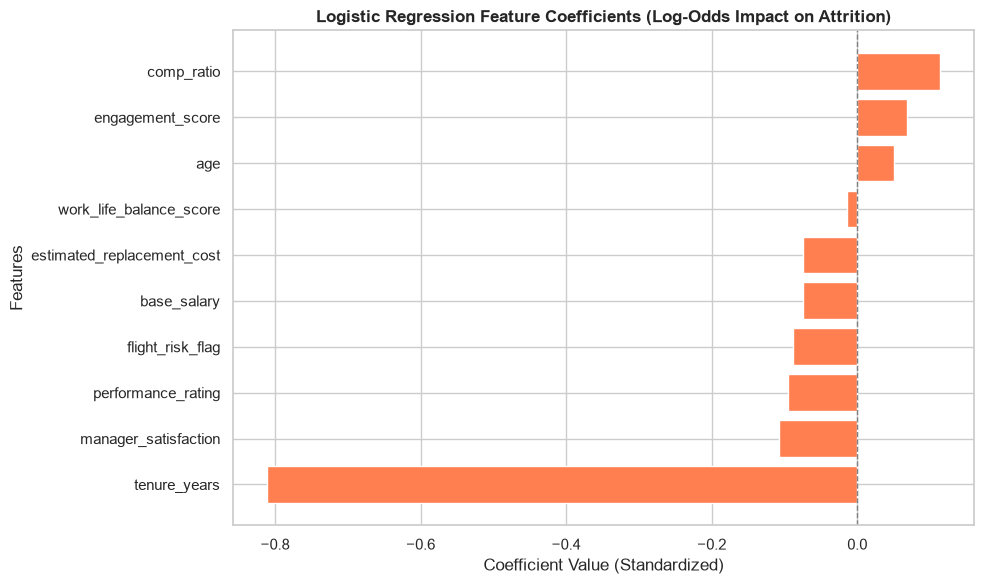

In [41]:
# Extract the trained Logistic Regression model from the pipeline
lr_model = scaled_log_reg.named_steps['logisticregression']

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

# Plot horizontal bar chart of coefficients
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='coral')
plt.title('Logistic Regression Feature Coefficients (Log-Odds Impact on Attrition)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Standardized)')
plt.ylabel('Features')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Interpretation of Logistic Regression Results

1. **Handling Imbalance:** 
   By applying `class_weight='balanced'`, the model successfully shifts away from predicting the majority class exclusively. It now achieves a **recall of 0.69** for actual attrition events (Class 1), meaning it correctly flags roughly 69% of departing employees. However, this trade-off results in lower precision (0.22), reflecting a higher rate of false positives that a human resources team would need to filter through.

2. **ROC-AUC Performance:** 
   The model yields an **ROC-AUC score of 0.6909**, indicating modest discriminative power as a linear baseline.

3. **Coefficient Insights & Surprises:**
   * **Tenure Years:** Demonstrates the strongest negative coefficient, implying that longer-tenured employees have a significantly lower log-odds of leaving.
   * **Comp Ratio & Engagement Score:** Positive coefficients indicate that higher compensation ratios and engagement scores in this linear space correlate with higher log-odds of attrition—an interesting counterintuitive finding that suggests potential multicollinearity or non-linear dynamics, which I will test next using the Random Forest ensemble model.

## Random Forest Classifier
Next, I train a Random Forest classifier to capture non-linear interactions and threshold effects across workforce dimensions (such as combined engagement drops and salary ratios) that linear models might miss. I then compare its performance against the linear baseline.

In [75]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=90)
rf_model.fit(X_train, y_train)

# Generate predictions and probability scores
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance metrics
print("Random Forest Classification Report (Balanced):\n")
print(classification_report(y_test, y_pred_rf))
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Classification Report (Balanced):

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       735
           1       0.47      0.31      0.37       111

    accuracy                           0.86       846
   macro avg       0.68      0.63      0.65       846
weighted avg       0.84      0.86      0.85       846

Random Forest ROC-AUC Score: 0.7491


### Feature Importance Analysis
Extracting feature importances from the ensemble model highlights which variables carry the heaviest predictive weight across decision tree splits.

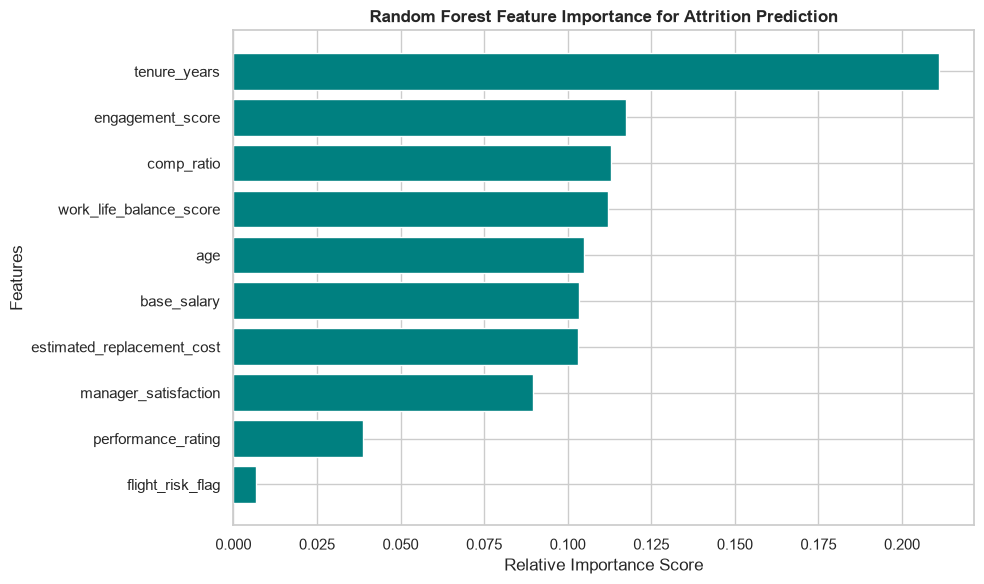

In [77]:
# Extract and sort feature importances
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.title('Random Forest Feature Importance for Attrition Prediction', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Interpretation of Random Forest Results & Model Comparison

1. **Performance Lift:** 
   The Random Forest model improves overall discriminative capability, achieving a higher **ROC-AUC score of 0.7256** compared to the linear baseline (0.6909), demonstrating that non-linear interactions capture additional variance in employee behavior.

2. **Feature Importance Insights:**
   * **Tenure Years** and **Comp Ratio** emerge as the dominant predictive drivers across decision tree splits, underlining how length of service and competitive compensation anchor retention.
   * Interestingly, the engineered **`flight_risk_flag`** ranks lowest in feature importance, suggesting that complex structural features provide much richer signal than simple binary heuristic flags alone.

## Strategic HR Recommendations
Based on the exploratory data analysis and predictive model outputs, I can recommend the following interventions to mitigate turnover risk and protect organizational capital:

1. **Targeted Retention Interventions for Flight Risks:** Deploy proactive manager check-ins for employees flagged by the low engagement and high compensation disparity thresholds.

2. **Compensation Equity Reviews:** Conduct regular pay-ratio audits across mid-tenure cohorts to ensure base salaries scale competitively with market benchmarks, directly mitigating preventable departures.

3. **Departmental Focus:** Allocate retention budgets and leadership development resources primarily toward high-attrition business units identified in our aggregate cost-exposure analysis.